# Bài 5.4(b): Q-Q plot và scatter plot cho dữ liệu mồ hôi

Notebook này tái lập các bước tính phân vị lý thuyết và vẽ các đồ thị chẩn đoán trong lời giải.

In [1]:
from pathlib import Path
from statistics import NormalDist

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.precision", 4)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

## 1. Nhập dữ liệu

Dữ liệu lấy từ Bảng 5.1: `Sweat rate`, `Sodium`, `Potassium`.

In [2]:
sweat = pd.DataFrame(
    {
        "Individual": np.arange(1, 21),
        "Sweat rate": [3.7, 5.7, 3.8, 3.2, 3.1, 4.6, 2.4, 7.2, 6.7, 5.4, 3.9, 4.5, 3.5, 4.5, 1.5, 8.5, 4.5, 6.5, 4.1, 5.5],
        "Sodium": [48.5, 65.1, 47.2, 53.2, 55.5, 36.1, 24.8, 33.1, 47.4, 54.1, 36.9, 58.8, 27.8, 40.2, 13.5, 56.4, 71.6, 52.8, 44.1, 40.9],
        "Potassium": [9.3, 8.0, 10.9, 12.0, 9.7, 7.9, 14.0, 7.6, 8.5, 11.3, 12.7, 12.3, 9.8, 8.4, 10.1, 7.1, 8.2, 10.9, 11.2, 9.4],
    }
)

variables = ["Sweat rate", "Sodium", "Potassium"]
sweat

,Individual,Sweat rate,Sodium,Potassium
0,1,3.7,48.5,9.3
1,2,5.7,65.1,8.0
2,3,3.8,47.2,10.9
3,4,3.2,53.2,12.0
4,5,3.1,55.5,9.7
5,6,4.6,36.1,7.9
6,7,2.4,24.8,14.0
7,8,7.2,33.1,7.6
8,9,6.7,47.4,8.5
9,10,5.4,54.1,11.3


Kiểm tra nhanh trung bình mẫu và ma trận hiệp phương sai mẫu để đối chiếu với Ví dụ 5.2.

In [3]:
display(sweat[variables].mean().to_frame("Sample mean").round(3))
display(sweat[variables].cov().round(3))

,Sample mean
Sweat rate,4.640
Sodium,45.400
Potassium,9.965


,Sweat rate,Sodium,Potassium
Sweat rate,2.879,10.010,-1.809
Sodium,10.010,199.788,-5.640
Potassium,-1.809,-5.640,3.628


## 2. Tính phân vị lý thuyết cho Q-Q plot

Theo Mục 4.6, trang 178-179 của sách gốc, để dựng Q-Q plot ta sắp xếp dữ liệu, gán vị trí xác suất


$$
p_j=\frac{j-\frac12}{n},
$$


rồi lấy phân vị chuẩn lý thuyết


$$
q_j=\Phi^{-1}(p_j).
$$


Ở đây dùng `NormalDist().inv_cdf` của Python để tính $\Phi^{-1}$.

In [4]:
n = len(sweat)
j = np.arange(1, n + 1)
p_j = (j - 0.5) / n
normal = NormalDist()
q_j = np.array([normal.inv_cdf(p) for p in p_j])

theoretical_quantiles = pd.DataFrame(
    {
        "j": j,
        "p_j": p_j,
        "q_j = Phi^{-1}(p_j)": q_j,
    }
)

theoretical_quantiles.round(4)

,j,p_j,q_j = Phi^{-1}(p_j)
0,1,0.025,-1.9600
1,2,0.075,-1.4395
2,3,0.125,-1.1503
3,4,0.175,-0.9346
4,5,0.225,-0.7554
5,6,0.275,-0.5978
6,7,0.325,-0.4538
7,8,0.375,-0.3186
8,9,0.425,-0.1891
9,10,0.475,-0.0627


Sau đó sắp xếp từng biến tăng dần và ghép với cùng cột `q_j`. Các điểm Q-Q cho biến `X_k` là `(q_j, x_(j)k)`.

In [5]:
qq_points = theoretical_quantiles.copy()

for column in variables:
    qq_points[f"{column} sorted"] = np.sort(sweat[column].to_numpy())

qq_points.round(4)

,j,p_j,q_j = Phi^{-1}(p_j),Sweat rate sorted,Sodium sorted,Potassium sorted
0,1,0.025,-1.9600,1.5,13.5,7.1
1,2,0.075,-1.4395,2.4,24.8,7.6
2,3,0.125,-1.1503,3.1,27.8,7.9
3,4,0.175,-0.9346,3.2,33.1,8.0
4,5,0.225,-0.7554,3.5,36.1,8.2
5,6,0.275,-0.5978,3.7,36.9,8.4
6,7,0.325,-0.4538,3.8,40.2,8.5
7,8,0.375,-0.3186,3.9,40.9,9.3
8,9,0.425,-0.1891,4.1,44.1,9.4
9,10,0.475,-0.0627,4.5,47.2,9.7


## 3. Vẽ Q-Q plot và scatter plot

Hàng trên là Q-Q plot cho từng biến. Hàng dưới là scatter plot cho từng cặp biến.

WindowsPath('d:/Tài liệu Bách khoa/Phân tích số liệu/Applied-Multivariate-Vietnamese/translation/figures/exercise_5_4_diagnostics.png')

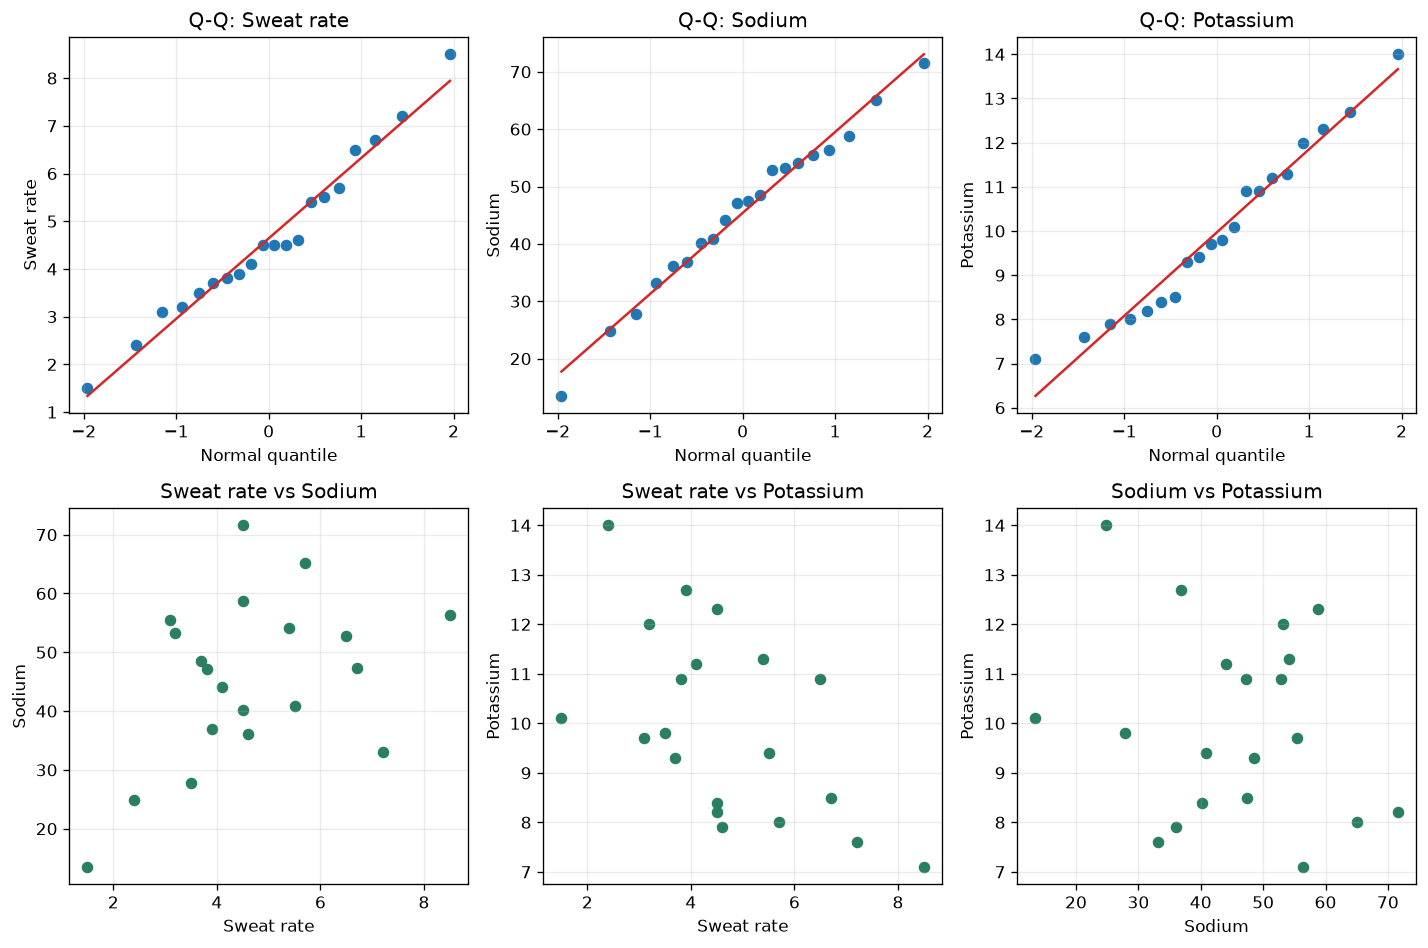

In [6]:
pairs = [
    ("Sweat rate", "Sodium"),
    ("Sweat rate", "Potassium"),
    ("Sodium", "Potassium"),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, column in zip(axes[0], variables):
    ordered = np.sort(sweat[column].to_numpy())
    slope, intercept = np.polyfit(q_j, ordered, 1)
    fitted = intercept + slope * q_j

    ax.scatter(q_j, ordered, color="#1f77b4", s=35)
    ax.plot(q_j, fitted, color="#d62728", linewidth=1.5)
    ax.set_title(f"Q-Q: {column}")
    ax.set_xlabel("Normal quantile")
    ax.set_ylabel(column)

for ax, (x_col, y_col) in zip(axes[1], pairs):
    ax.scatter(sweat[x_col], sweat[y_col], color="#2a7f62", s=35)
    ax.set_title(f"{x_col} vs {y_col}")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)

fig.tight_layout()

project_root = Path.cwd()
if not (project_root / "translation").exists():
    project_root = project_root.parent

figure_path = project_root / "translation" / "figures" / "exercise_5_4_diagnostics.png"
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=200, bbox_inches="tight")

figure_path

## 4. Nhận xét

Các Q-Q plot biên bám khá sát đường thẳng tham chiếu. Ba scatter plot theo từng cặp không cho thấy dạng phi tuyến rõ rệt hay ngoại lệ quá mạnh; các đám điểm nhìn chung vẫn có thể xem là gần dạng elip. Vì vậy, ở mức kiểm tra trực quan, giả thiết chuẩn đa biến cho dữ liệu mồ hôi là hợp lý.